<a href="https://colab.research.google.com/github/Sodabeh-Taherpanah/ML-examples/blob/main/last_ML_assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# User Engagement Metrics & Website Traffic


***The Business Problem:***

In This project we want to inspect how visitors behave on an online shop then we can  find out what leads them to make a purchase. By analyzing  page views, session time, and traffic sources(website statistics), we aim to understand what drives engagement. So we focus on predicting and improving the Conversion Rate — the percentage of users who become customers.



***Collection data:***


<font color='teal'>I got it from Kaggle, This dataset provides key factors of web traffic. this dataset has below columns:</font>

```
# Dataset Url : https://www.kaggle.com/code/musagodwin/web-traffic-marketing-analysis/input
```

*   The number of pages viewed during a session.
*   The total duration of the session in minutes.
*   The percentage of visitors who navigate away from the site after viewing only one page.
*   The origin of the traffic (e.g., Organic, Social, Paid).The amount of time spent on the specific page.
*   The number of previous visits by the same visitor.
*   The percentage of visitors who completed a desired action (e.g., making a purchase).



In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, RepeatedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = pd.read_csv('websiteWata.csv')
data.head()

,Page Views,Session Duration,Bounce Rate,Traffic Source,Time on Page,Previous Visits,Conversion Rate
0,5.0,11.051381,NaN,Organic,3.890460,3.0,1.0
1,NaN,3.429316,0.391001,Social,NaN,0.0,1.0
2,NaN,1.621052,0.397986,Organic,NaN,NaN,NaN
3,5.0,3.629279,NaN,Organic,2.071925,NaN,1.0
4,5.0,4.235843,NaN,Paid,1.960654,NaN,NaN


So according to our request to more sales we chose <font color='teal'>**Conversion Rate**</font> as our target. As a result optimizing it improves profitability without increasing traffic costs.


***Business Benefit Summary:***

Predicting conversion rate allows the company to improve page experience, target the most valuable traffic sources, and personalize experiences for return users


<font color='teal'>***All leading to more sales***.</font>

In [94]:

print("Duplicate:\n\n", data.duplicated().sum())

print("Column types:\n", data.dtypes)


Duplicate:

 21
Column types:
 Page Views          float64
Session Duration    float64
Bounce Rate         float64
Traffic Source       object
Time on Page        float64
Previous Visits     float64
Conversion Rate     float64
dtype: object



***Separating the features and  target variable***

<font color='teal'>We chose 'Conversion Rate' as the target variable because it is the final outcome metric that reflects the success of all marketing, and content strategies combined.</font>

In [95]:
X = data.drop('Conversion Rate', axis=1)
y = data['Conversion Rate']


<font color='teal'>Encode categorical variables for this column to convert it to numerical.</font>

In [97]:
label_encoder = LabelEncoder()
X['Traffic Source'] = label_encoder.fit_transform(X['Traffic Source'])


***Handle missing values:***

<font color='teal'>
Now For ensuring completeness of the dataset Missing values are filled using the mean strategy, as you see our features are highly skewed, so we consider median strategy and do not drop missing y,becuase that hurt our results </font>


array([[<Axes: title={'center': 'Page Views'}>,
        <Axes: title={'center': 'Session Duration'}>],
       [<Axes: title={'center': 'Bounce Rate'}>,
        <Axes: title={'center': 'Traffic Source'}>],
       [<Axes: title={'center': 'Time on Page'}>,
        <Axes: title={'center': 'Previous Visits'}>]], dtype=object)

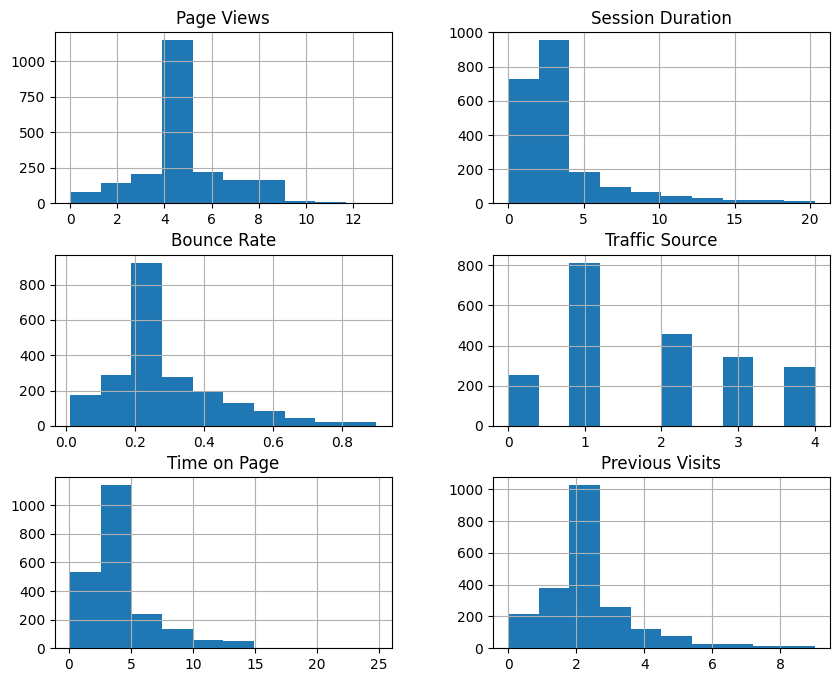

In [98]:

imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

y = y.fillna(y.mean())  # Fill NaN values in target with the mean

X.hist(figsize=(10,8))

***Add some features & Scaling:***

 <font color='teal'>Consider If a user views many pages and spends a long time per page, this engagement leads to a higher conversion rate. </font>

 <font color='red'>So multiplying these factors has more meaning and more effect. This part causes high correlation, so maybe it increases cross-validation but finally, it hurts our r-square and increases overfitting.  </font>

In [88]:

X["Page Views * Time on Page"] = X["Page Views"] * X["Time on Page"]
X["Log_Session_Duration"] = np.log1p(X["Session Duration"])
X["Log_Previous_Visits"] = np.log1p(X["Previous Visits"])

***The distribution of a feature with histplot:***

  <font color='teal'>We have left-skewed data for Session Duration. we normalized with np.log1p().reslut is less for Previous Visits, but better than original.</font>


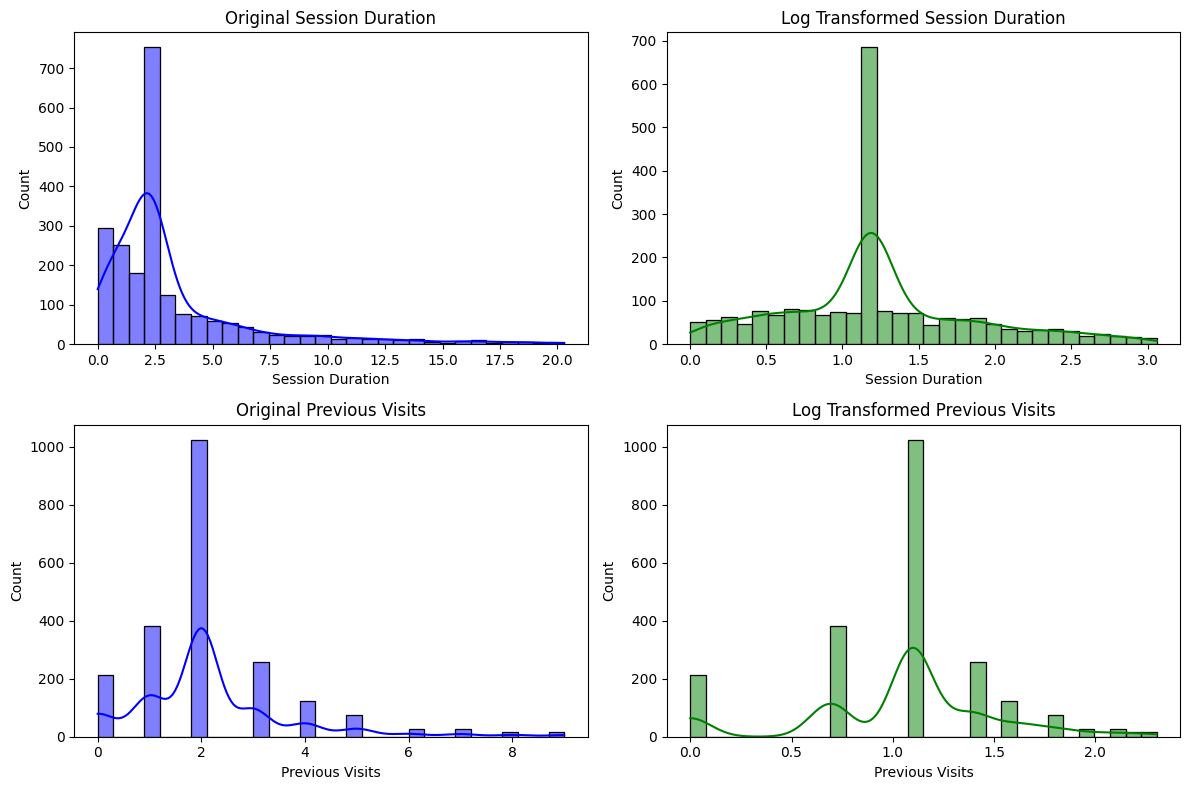

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features = ["Session Duration", "Previous Visits"]

# subplots creates a feature
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

for i, feature in enumerate(features):
    row = i

    #  original distribution
    sns.histplot(X[feature], bins=30, kde=True, ax=axes[row, 0], color="blue")
    axes[row, 0].set_title(f"Original {feature}")

    #  log-transformed distribution
    sns.histplot(np.log1p(X[feature]), bins=30, kde=True, ax=axes[row, 1], color="green")
    axes[row, 1].set_title(f"Log Transformed {feature}")

plt.tight_layout()
plt.show()


***Scaling:***

<font color='teal'>Scaling ensures distance-based algorithms like KNN work optimally.</font>

In [100]:

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


***Check correlation matrix:***

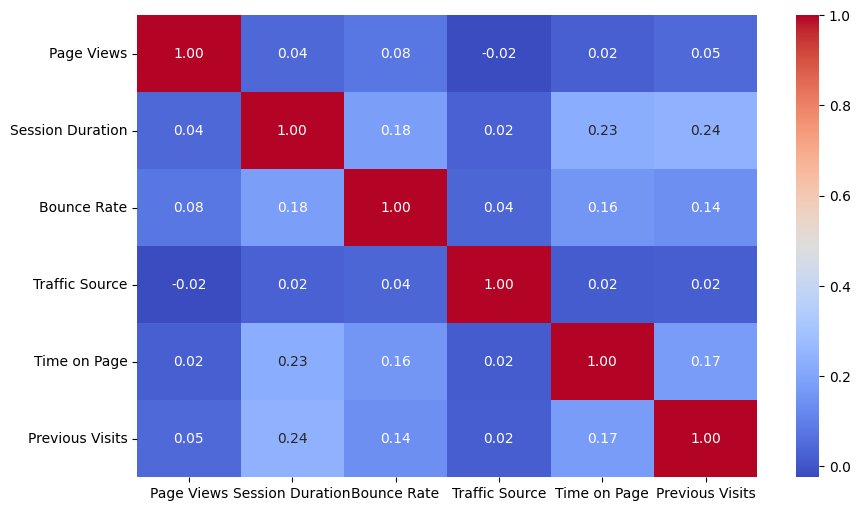

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()


***Model Training: K-Nearest Neighbors (KNN):***

<font color='teal'>We use RandomizedSearchCV to find the best combination of hyperparameters for the KNN model</font>

Why KNN:
1.  Simpler
2.   More interpretable
3.   Better R² and lower MSE
4.   Easier to visualize and explain to stakeholders

** This  dataset had missing values in several features and required encoding of categorical variables. No large imbalance was found in the target variable.
Because the goal was regression, we used R² and MSE as our evaluation metrics.

In [111]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=42)


knn = KNeighborsRegressor()

# Set up our hyperparameter
param_grid = {
    'n_neighbors': [5, 7, 9,11,13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'leaf_size': [20, 30, 40,50],
    'p': [1, 2]
}

# Repeated cross-validation strategy
cv = RepeatedKFold(n_splits=5, n_repeats=30, random_state=42)


random_search = RandomizedSearchCV(knn, param_distributions=param_grid, n_iter=50, cv=cv, scoring="r2", n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)


print(f"Best parameters: {random_search.best_params_}")


Best parameters: {'weights': 'distance', 'p': 2, 'n_neighbors': 9, 'metric': 'manhattan', 'leaf_size': 50}


***Model Evaluation***

In [110]:

# Cross-validation scores
cross_val_scores = cross_val_score(random_search.best_estimator_, X_train, y_train, cv=5, scoring='r2')

print("Cross-validated R² scores: ", cross_val_scores)
print("Mean Cross-validated R² score: ", cross_val_scores.mean())
print("Standard Deviation: ", cross_val_scores.std())

#predictions of test -set
y_pred = random_search.predict(X_test)

# Our Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Cross-validated R² scores:  [0.3577425  0.39516797 0.25011013 0.19085937 0.36929707]
Mean Cross-validated R² score:  0.31263540852079036
Standard Deviation:  0.07848009856575808
Mean Squared Error: 0.00853295081957565
R-squared: 0.5806193802686708




***Finding:***

At first my result for KNN was:
Cv R² score:  0.34
SD:  0.09854483425093293
MSquared Error: 0.0089
Rs: 0.48

Afte changing hyperparametters R² was 0.5800.

Although the first model seems to have better cross-validation performance on average, the second model's test set R² indicates better generalization for actual deployment and prediction on new data specially for  our online shop.

<font color='teal'>This plot shows how closely the predicted conversion rates align with the actual values.</font>


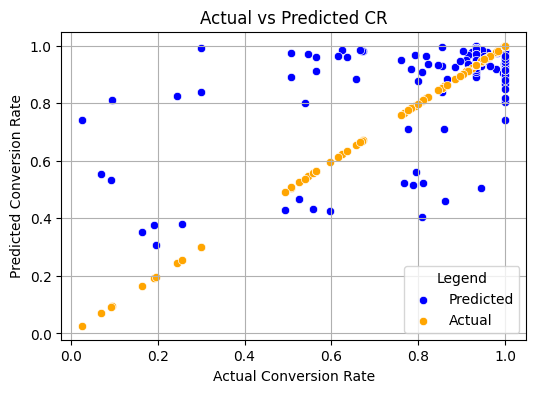

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

# Scatter : actual vs predicted
sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Predicted')
sns.scatterplot(x=y_test, y=y_test, color='orange', label='Actual')


plt.xlabel("Actual Conversion Rate")
plt.ylabel("Predicted Conversion Rate")
plt.title("Actual vs Predicted CR")

plt.grid(True)
plt.legend(title="Legend")

plt.show()


**Comparison KNN / Random Forest**

<font color='teal'>Despite Random Forest being a strong algorithm, KNN outperformed it on both accuracy and error and KNN offered **more stable and reliable**</font>

***Random Forest:***

<font color='teal'>While It had a relatively higher R² on test set, it also had a higher Mean Squared Error and lower cross-validation performance.</font>

<font color='red'>But This suggests potential overfitting or instability — possibly due to data size or feature noise.</font>


Random Forest MSE: 0.011922355552760036
Random Forest R²: 0.41403566408666914


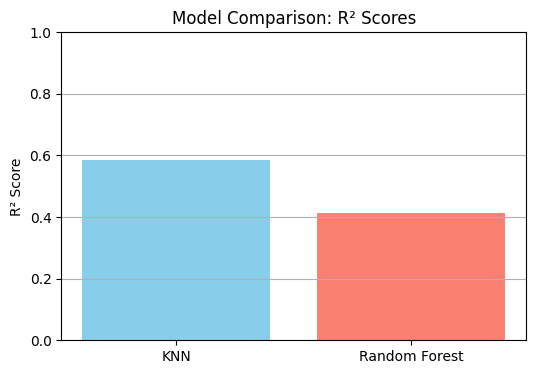

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_rf_pred = rf.predict(X_test)
rf_mse = mean_squared_error(y_test, y_rf_pred)
rf_r2 = r2_score(y_test, y_rf_pred)
print("Random Forest MSE:", rf_mse)
print("Random Forest R²:", rf_r2)

# Visual comparison of KNN vs Random Forest R²
models = ['KNN', 'Random Forest']
r2_scores = [r2, rf_r2]

plt.figure(figsize=(6, 4))
plt.bar(models, r2_scores, color=['skyblue', 'salmon'])
plt.title("Model Comparison: R² Scores")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(True, axis='y')
plt.show()



***My Insights & Recommendations:***


* We should focus on increasing Session Duration and Page Views maybe adding more gmification or attractive banners, better content can be helpful specially on landing pages.
*   We should prioritize traffic sources that yield higher conversions

* Personalize content for returning users according to their search and show tailored offers to returning users.

* Also we can increase our data  and refine low-performing pages: Then we will use conversion heatmaps and scroll-depth analysis to identify where users lose interest.

* We suggest A/B testing website changes that aim to increase engagement metrics.
